In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df= pd.read_csv('uberdrive.csv')

In [277]:
df.head()

,START_DATE*,END_DATE*,CATEGORY*,START*,STOP*,MILES*,PURPOSE*,DATE,TIME,DAY-NIGHT,MONTH,WEEKDAYS,MINUTES
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21,Night,1,Friday,0 days 00:06:00
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,NOT,2016-01-02,1,Middle of Night,1,Saturday,0 days 00:12:00
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-01-02,20,Evening,1,Saturday,0 days 00:13:00
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-01-05,17,Evening,1,Tuesday,0 days 00:14:00
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016-01-06,14,Afternoon,1,Wednesday,0 days 01:07:00


In [278]:
df.tail()

,START_DATE*,END_DATE*,CATEGORY*,START*,STOP*,MILES*,PURPOSE*,DATE,TIME,DAY-NIGHT,MONTH,WEEKDAYS,MINUTES
1149,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Kar?chi,Kar?chi,0.8,Customer Visit,2016-01-01,21,Night,1,Friday,0 days 00:06:00
1150,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Kar?chi,Kar?chi,0.7,Meeting,2016-01-01,21,Night,1,Friday,0 days 00:06:00
1151,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Kar?chi,Unknown Location,3.9,Temporary Site,2016-01-01,21,Night,1,Friday,0 days 00:06:00
1153,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Katunayake,Gampaha,6.4,Temporary Site,2016-01-01,21,Night,1,Friday,0 days 00:06:00
1154,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Gampaha,Ilukwatta,48.2,Temporary Site,2016-01-01,21,Night,1,Friday,0 days 00:06:00


In [280]:
df.shape

(1099, 13)

In [281]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1099 entries, 0 to 1154
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype          
---  ------       --------------  -----          
 0   START_DATE*  1099 non-null   datetime64[ns] 
 1   END_DATE*    1099 non-null   datetime64[ns] 
 2   CATEGORY*    1099 non-null   object         
 3   START*       1099 non-null   object         
 4   STOP*        1099 non-null   object         
 5   MILES*       1099 non-null   float64        
 6   PURPOSE*     1099 non-null   object         
 7   DATE         1099 non-null   object         
 8   TIME         1099 non-null   int32          
 9   DAY-NIGHT    1099 non-null   category       
 10  MONTH        1099 non-null   int32          
 11  WEEKDAYS     1099 non-null   object         
 12  MINUTES      1099 non-null   timedelta64[ns]
dtypes: category(1), datetime64[ns](2), float64(1), int32(2), object(6), timedelta64[ns](1)
memory usage: 104.3+ KB


In [10]:
df.columns

Index(['START_DATE*', 'END_DATE*', 'CATEGORY*', 'START*', 'STOP*', 'MILES*',
       'PURPOSE*'],
      dtype='object')

In [11]:
df.size

8092

In [20]:
df.drop(df.index[-1],inplace = True)

In [21]:
df.tail()

,START_DATE*,END_DATE*,CATEGORY*,START*,STOP*,MILES*,PURPOSE*
1150,12/31/2016 1:07,12/31/2016 1:14,Business,Kar?chi,Kar?chi,0.7,Meeting
1151,12/31/2016 13:24,12/31/2016 13:42,Business,Kar?chi,Unknown Location,3.9,Temporary Site
1152,12/31/2016 15:03,12/31/2016 15:38,Business,Unknown Location,Unknown Location,16.2,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


In [203]:
df['START*'].value_counts()

START*
Cary                186
Unknown Location    137
Morrisville          78
Whitebridge          64
Islamabad            54
                   ... 
Krendle Woods         1
Fuquay-Varina         1
Wake Co.              1
Katunayake            1
Gampaha               1
Name: count, Length: 177, dtype: int64

In [204]:
df.dtypes

START_DATE*     datetime64[ns]
END_DATE*       datetime64[ns]
CATEGORY*               object
START*                  object
STOP*                   object
MILES*                 float64
PURPOSE*                object
DATE                    object
TIME                     int32
DAY-NIGHT             category
MONTH                   object
WEEKDAYS                object
MINUTES        timedelta64[ns]
dtype: object

In [202]:
df.describe()

,START_DATE*,END_DATE*,MILES*,TIME,MINUTES
count,1099,1099,1099.000000,1099.000000,1099
mean,2016-03-11 11:08:17.852593152,2016-03-11 07:06:21.838034432,10.794540,18.696997,-1 days +19:58:03.985441311
min,2016-01-01 21:11:00,2016-01-01 21:17:00,0.500000,0.000000,-194 days +21:30:00
25%,2016-01-01 21:11:00,2016-01-01 21:17:00,2.800000,17.000000,0 days 00:06:00
50%,2016-01-01 21:11:00,2016-01-01 21:17:00,6.000000,21.000000,0 days 00:06:00
75%,2016-05-06 11:16:00,2016-05-06 03:05:00,10.600000,21.000000,0 days 00:12:00
max,2016-12-12 20:48:00,2016-12-12 20:57:00,310.300000,23.000000,0 days 02:58:00
std,NaN,NaN,22.079844,4.109399,5 days 19:48:17.107495771


In [205]:
df.describe(include = ['object'])

,CATEGORY*,START*,STOP*,PURPOSE*,DATE,MONTH,WEEKDAYS
count,1099,1099,1099,1099,1099,1099,1099
unique,2,177,188,11,114,12,7
top,Business,Cary,Cary,NOT,2016-01-01,Jan,Friday
freq,1023,186,187,481,679,701,765


In [206]:
df.isnull().sum()

START_DATE*    0
END_DATE*      0
CATEGORY*      0
START*         0
STOP*          0
MILES*         0
PURPOSE*       0
DATE           0
TIME           0
DAY-NIGHT      0
MONTH          0
WEEKDAYS       0
MINUTES        0
dtype: int64

In [209]:
import warnings
warnings.filterwarnings("ignore")
df['PURPOSE*'].fillna('NOT',inplace = True)

In [210]:
df.isnull().sum()

START_DATE*    0
END_DATE*      0
CATEGORY*      0
START*         0
STOP*          0
MILES*         0
PURPOSE*       0
DATE           0
TIME           0
DAY-NIGHT      0
MONTH          0
WEEKDAYS       0
MINUTES        0
dtype: int64

In [211]:
df[df.duplicated()]

,START_DATE*,END_DATE*,CATEGORY*,START*,STOP*,MILES*,PURPOSE*,DATE,TIME,DAY-NIGHT,MONTH,WEEKDAYS,MINUTES


In [212]:
df.drop_duplicates(inplace = True)

In [213]:
df[df.duplicated()]

,START_DATE*,END_DATE*,CATEGORY*,START*,STOP*,MILES*,PURPOSE*,DATE,TIME,DAY-NIGHT,MONTH,WEEKDAYS,MINUTES


In [214]:
df.head()

,START_DATE*,END_DATE*,CATEGORY*,START*,STOP*,MILES*,PURPOSE*,DATE,TIME,DAY-NIGHT,MONTH,WEEKDAYS,MINUTES
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21,Night,Jan,Friday,0 days 00:06:00
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,NOT,2016-01-02,1,Middle of Night,Jan,Saturday,0 days 00:12:00
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-01-02,20,Evening,Jan,Saturday,0 days 00:13:00
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-01-05,17,Evening,Jan,Tuesday,0 days 00:14:00
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016-01-06,14,Afternoon,Jan,Wednesday,0 days 01:07:00


In [215]:
pd.to_datetime(df['START_DATE*'], errors = 'coerce')

0      2016-01-01 21:11:00
1      2016-01-02 01:25:00
2      2016-01-02 20:25:00
3      2016-01-05 17:31:00
4      2016-01-06 14:42:00
               ...        
1149   2016-01-01 21:11:00
1150   2016-01-01 21:11:00
1151   2016-01-01 21:11:00
1153   2016-01-01 21:11:00
1154   2016-01-01 21:11:00
Name: START_DATE*, Length: 1099, dtype: datetime64[ns]

In [216]:
pd.to_datetime(df['END_DATE*'], errors = 'coerce')

0      2016-01-01 21:17:00
1      2016-01-02 01:37:00
2      2016-01-02 20:38:00
3      2016-01-05 17:45:00
4      2016-01-06 15:49:00
               ...        
1149   2016-01-01 21:17:00
1150   2016-01-01 21:17:00
1151   2016-01-01 21:17:00
1153   2016-01-01 21:17:00
1154   2016-01-01 21:17:00
Name: END_DATE*, Length: 1099, dtype: datetime64[ns]

In [217]:
df['START_DATE*'] = pd.to_datetime(df['START_DATE*'], errors = 'coerce')

df['END_DATE*'] = pd.to_datetime(df['END_DATE*'], errors = 'coerce')

df['DATE'] = pd.DatetimeIndex(df['START_DATE*']).date

df['TIME'] = pd.DatetimeIndex(df['START_DATE*']).hour

In [218]:
df['DAY-NIGHT'] = pd.cut(x = df['TIME'], bins = [0,10,15,19,20], labels = ['Morning', 'Afternoon', 'Evening', 'Night'])

In [219]:
pd.cut(x = df['TIME'], bins = [0,10,15,19,20], labels = ['Morning', 'Afternoon', 'Evening', 'Night'])

0             NaN
1         Morning
2           Night
3         Evening
4       Afternoon
          ...    
1149          NaN
1150          NaN
1151          NaN
1153          NaN
1154          NaN
Name: TIME, Length: 1099, dtype: category
Categories (4, object): ['Morning' < 'Afternoon' < 'Evening' < 'Night']

In [221]:
df.isnull().sum()

START_DATE*      0
END_DATE*        0
CATEGORY*        0
START*           0
STOP*            0
MILES*           0
PURPOSE*         0
DATE             0
TIME             0
DAY-NIGHT      731
MONTH            0
WEEKDAYS         0
MINUTES          0
dtype: int64

In [223]:
df.isnull().sum().index

Index(['START_DATE*', 'END_DATE*', 'CATEGORY*', 'START*', 'STOP*', 'MILES*',
       'PURPOSE*', 'DATE', 'TIME', 'DAY-NIGHT', 'MONTH', 'WEEKDAYS',
       'MINUTES'],
      dtype='object')

In [224]:
df.select_dtypes(include = [np.number]).columns

Index(['MILES*', 'TIME', 'MINUTES'], dtype='object')

In [225]:
numerical_null_values = df.select_dtypes(include = [np.number]).columns

numerical_null_values = list (numerical_null_values)

In [226]:
for value in numerical_null_values:
    median = df[value].mean()
    df[value].replace(np.nan, median, inplace = True)

In [228]:
df.isnull().sum()

START_DATE*      0
END_DATE*        0
CATEGORY*        0
START*           0
STOP*            0
MILES*           0
PURPOSE*         0
DATE             0
TIME             0
DAY-NIGHT      731
MONTH            0
WEEKDAYS         0
MINUTES          0
dtype: int64

In [229]:
df.select_dtypes(exclude = [np.number]).columns

Index(['START_DATE*', 'END_DATE*', 'CATEGORY*', 'START*', 'STOP*', 'PURPOSE*',
       'DATE', 'DAY-NIGHT', 'MONTH', 'WEEKDAYS'],
      dtype='object')

In [230]:
non_numerical_null_values = df.select_dtypes(exclude = [np.number]).columns

In [231]:
non_numerical_null_values = list(non_numerical_null_values)

for value in non_numerical_null_values:
    mode_value = df[value].mode()[0]
    df[value].fillna(mode_value,inplace = True)

In [232]:
df.isnull().sum()

START_DATE*    0
END_DATE*      0
CATEGORY*      0
START*         0
STOP*          0
MILES*         0
PURPOSE*       0
DATE           0
TIME           0
DAY-NIGHT      0
MONTH          0
WEEKDAYS       0
MINUTES        0
dtype: int64

In [233]:
df['START*'].value_counts()

START*
Cary                186
Unknown Location    137
Morrisville          78
Whitebridge          64
Islamabad            54
                   ... 
Krendle Woods         1
Fuquay-Varina         1
Wake Co.              1
Katunayake            1
Gampaha               1
Name: count, Length: 177, dtype: int64

In [52]:
df

,START_DATE*,END_DATE*,CATEGORY*,START*,STOP*,MILES*,PURPOSE*,DATE,TIME,DAY-NIGHT
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21.0,NaN
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,NOT,2016-01-02,1.0,Morning
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-01-02,20.0,Night
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-01-05,17.0,Evening
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016-01-06,14.0,Afternoon
...,...,...,...,...,...,...,...,...,...,...
1150,NaT,NaT,Business,Kar?chi,Kar?chi,0.7,Meeting,NaT,NaN,NaN
1151,NaT,NaT,Business,Kar?chi,Unknown Location,3.9,Temporary Site,NaT,NaN,NaN
1152,NaT,NaT,Business,Unknown Location,Unknown Location,16.2,Meeting,NaT,NaN,NaN
1153,NaT,NaT,Business,Katunayake,Gampaha,6.4,Temporary Site,NaT,NaN,NaN


In [234]:
df.duplicated()

dups = df.duplicated()
print("number of dupicated row = %d" %(dups.sum()))

df[dups]
      

number of dupicated row = 0


,START_DATE*,END_DATE*,CATEGORY*,START*,STOP*,MILES*,PURPOSE*,DATE,TIME,DAY-NIGHT,MONTH,WEEKDAYS,MINUTES


In [235]:
df.drop_duplicates(inplace = True)

In [236]:
df.duplicated()

dups = df.duplicated()
print("number of dupicated row = %d" %(dups.sum()))

df[dups]

number of dupicated row = 0


,START_DATE*,END_DATE*,CATEGORY*,START*,STOP*,MILES*,PURPOSE*,DATE,TIME,DAY-NIGHT,MONTH,WEEKDAYS,MINUTES


In [282]:
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 1099 entries, 0 to 1154
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype          
---  ------       --------------  -----          
 0   START_DATE*  1099 non-null   datetime64[ns] 
 1   END_DATE*    1099 non-null   datetime64[ns] 
 2   CATEGORY*    1099 non-null   object         
 3   START*       1099 non-null   object         
 4   STOP*        1099 non-null   object         
 5   MILES*       1099 non-null   float64        
 6   PURPOSE*     1099 non-null   object         
 7   DATE         1099 non-null   object         
 8   TIME         1099 non-null   int32          
 9   DAY-NIGHT    1099 non-null   category       
 10  MONTH        1099 non-null   int32          
 11  WEEKDAYS     1099 non-null   object         
 12  MINUTES      1099 non-null   timedelta64[ns]
dtypes: category(1), datetime64[ns](2), float64(1), int32(2), object(6), timedelta64[ns](1)
memory usage: 104.3+ KB


np.int64(0)

In [78]:
pd.to_datetime(df['START_DATE*'], errors = 'coerce')

0      2016-01-01 21:11:00
1      2016-01-02 01:25:00
2      2016-01-02 20:25:00
3      2016-01-05 17:31:00
4      2016-01-06 14:42:00
               ...        
1149   2016-01-01 21:11:00
1150   2016-01-01 21:11:00
1151   2016-01-01 21:11:00
1153   2016-01-01 21:11:00
1154   2016-01-01 21:11:00
Name: START_DATE*, Length: 1099, dtype: datetime64[ns]

In [238]:
pd.to_datetime(df['END_DATE*'], errors = 'coerce')

0      2016-01-01 21:17:00
1      2016-01-02 01:37:00
2      2016-01-02 20:38:00
3      2016-01-05 17:45:00
4      2016-01-06 15:49:00
               ...        
1149   2016-01-01 21:17:00
1150   2016-01-01 21:17:00
1151   2016-01-01 21:17:00
1153   2016-01-01 21:17:00
1154   2016-01-01 21:17:00
Name: END_DATE*, Length: 1099, dtype: datetime64[ns]

In [239]:
df['START_DATE*'] = pd.to_datetime(df['START_DATE*'], errors = 'coerce')

df['END_DATE*'] = pd.to_datetime(df['END_DATE*'], errors = 'coerce')

df['DATE'] = pd.DatetimeIndex(df['START_DATE*']).date

df['TIME'] = pd.DatetimeIndex(df['START_DATE*']).hour

In [240]:
df['DAY-NIGHT'] = pd.cut(x = df['TIME'], bins = [0,5,12,16,20,24], labels = ['Middle of Night','Morning', 'Afternoon', 'Evening', 'Night'])

In [260]:
pd.cut(x = df['TIME'], bins = [0,5,12,16,20,24], labels = ['Middle of Night','Morning', 'Afternoon', 'Evening', 'Night'])

0                 Night
1       Middle of Night
2               Evening
3               Evening
4             Afternoon
             ...       
1149              Night
1150              Night
1151              Night
1153              Night
1154              Night
Name: TIME, Length: 1099, dtype: category
Categories (5, object): ['Middle of Night' < 'Morning' < 'Afternoon' < 'Evening' < 'Night']

In [142]:
df.head()

,START_DATE*,END_DATE*,CATEGORY*,START*,STOP*,MILES*,PURPOSE*,DATE,TIME,DAY-NIGHT,MONTH,WEEKDAYS
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21,Night,1,Friday
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,NOT,2016-01-02,1,Middle of Night,1,Saturday
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-01-02,20,Evening,1,Saturday
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-01-05,17,Evening,1,Tuesday
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016-01-06,14,Afternoon,1,Wednesday


In [261]:
df.isnull().sum()

START_DATE*    0
END_DATE*      0
CATEGORY*      0
START*         0
STOP*          0
MILES*         0
PURPOSE*       0
DATE           0
TIME           0
DAY-NIGHT      0
MONTH          0
WEEKDAYS       0
MINUTES        0
dtype: int64

In [262]:
non_numerical_null_values = df.select_dtypes(exclude = [np.number]).columns

In [263]:
non_numerical_null_values = list(non_numerical_null_values)

for value in non_numerical_null_values:
    mode_value = df[value].mode()[0]
    df[value].fillna(mode_value,inplace = True)

In [246]:
df.isnull().sum()

START_DATE*    0
END_DATE*      0
CATEGORY*      0
START*         0
STOP*          0
MILES*         0
PURPOSE*       0
DATE           0
TIME           0
DAY-NIGHT      0
MONTH          0
WEEKDAYS       0
MINUTES        0
dtype: int64

In [266]:
df['MONTH'] = pd.to_datetime(df['START_DATE*']).dt.month

In [267]:
df['MONTH']

0       1
1       1
2       1
3       1
4       1
       ..
1149    1
1150    1
1151    1
1153    1
1154    1
Name: MONTH, Length: 1099, dtype: int32

In [268]:
dict = {1:'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'June', 7: 'July', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12:'Dec'}

In [257]:
df['MONTH'].map(dict)

0       Jan
1       Jan
2       Jan
3       Jan
4       Jan
       ... 
1149    Jan
1150    Jan
1151    Jan
1153    Jan
1154    Jan
Name: MONTH, Length: 1099, dtype: object

In [258]:
df['MONTH'] = df['MONTH'].map(dict)

In [252]:
df.head()

,START_DATE*,END_DATE*,CATEGORY*,START*,STOP*,MILES*,PURPOSE*,DATE,TIME,DAY-NIGHT,MONTH,WEEKDAYS,MINUTES
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21,Night,Jan,Friday,0 days 00:06:00
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,NOT,2016-01-02,1,Middle of Night,Jan,Saturday,0 days 00:12:00
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-01-02,20,Evening,Jan,Saturday,0 days 00:13:00
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-01-05,17,Evening,Jan,Tuesday,0 days 00:14:00
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016-01-06,14,Afternoon,Jan,Wednesday,0 days 01:07:00


In [253]:
df['START_DATE*'].dt.day_name()

0          Friday
1        Saturday
2        Saturday
3         Tuesday
4       Wednesday
          ...    
1149       Friday
1150       Friday
1151       Friday
1153       Friday
1154       Friday
Name: START_DATE*, Length: 1099, dtype: object

In [259]:
df['WEEKDAYS'] = df['START_DATE*'].dt.day_name()

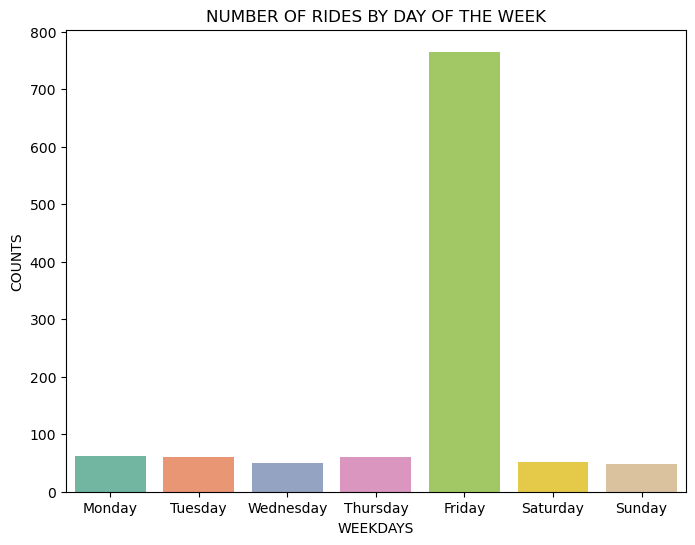

In [189]:
df['WEEKDAYS'] = df['START_DATE*'].dt.day_name()

## to view in plot

plt.figure(figsize = (8,6))
sns.countplot(data = df, x = 'WEEKDAYS', order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday','Friday','Saturday', 'Sunday'], palette = 'Set2')
plt.title('NUMBER OF RIDES BY DAY OF THE WEEK')
plt.xlabel('WEEKDAYS')
plt.ylabel('COUNTS')
plt.show()

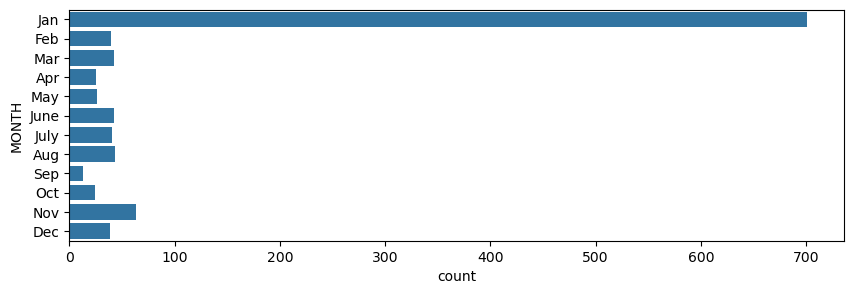

In [168]:
plt.figure(figsize = (10,3))
sns.countplot(df['MONTH'])
plt.show()

In [157]:
df['END_DATE*'] - df['START_DATE*']

0      0 days 00:06:00
1      0 days 00:12:00
2      0 days 00:13:00
3      0 days 00:14:00
4      0 days 01:07:00
             ...      
1149   0 days 00:06:00
1150   0 days 00:06:00
1151   0 days 00:06:00
1153   0 days 00:06:00
1154   0 days 00:06:00
Length: 1099, dtype: timedelta64[ns]

In [158]:
df['MINUTES'] = df['END_DATE*'] - df['START_DATE*']

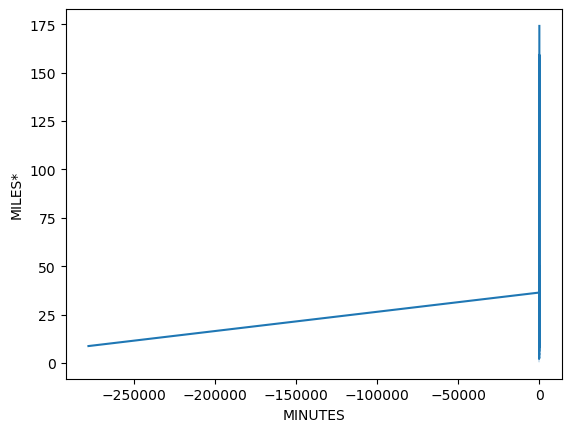

In [160]:
sns.lineplot(data = df, x = df['MINUTES'].dt.total_seconds()/60, y = df['MILES*'])
plt.show()

In [159]:
df.head()

,START_DATE*,END_DATE*,CATEGORY*,START*,STOP*,MILES*,PURPOSE*,DATE,TIME,DAY-NIGHT,MONTH,WEEKDAYS,MINUTES
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21,Night,1,Friday,0 days 00:06:00
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,NOT,2016-01-02,1,Middle of Night,1,Saturday,0 days 00:12:00
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-01-02,20,Evening,1,Saturday,0 days 00:13:00
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-01-05,17,Evening,1,Tuesday,0 days 00:14:00
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016-01-06,14,Afternoon,1,Wednesday,0 days 01:07:00


### Ride Category Analysis 

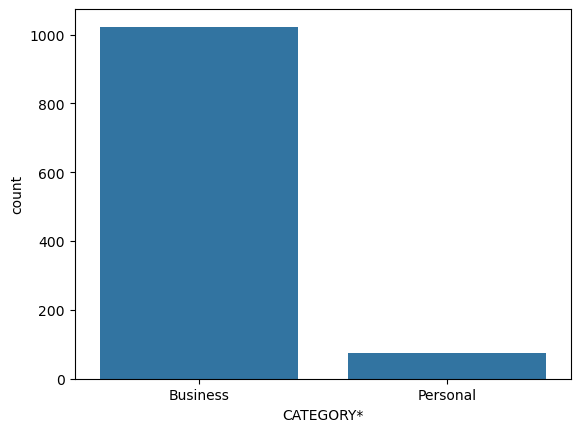

In [148]:
df['CATEGORY*'].value_counts()
sns.countplot(data = df, x = 'CATEGORY*')
plt.show()

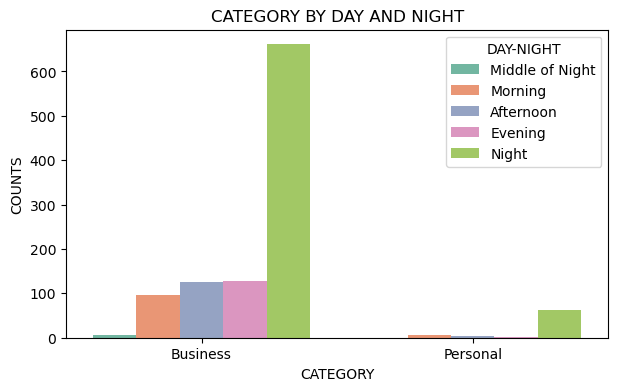

In [181]:
plt.figure(figsize = (7,4))
sns.countplot(data = df, x = 'CATEGORY*', hue = 'DAY-NIGHT', palette = 'Set2')
plt.title('CATEGORY BY DAY AND NIGHT')
plt.xlabel('CATEGORY')
plt.ylabel('COUNTS')
plt.show()

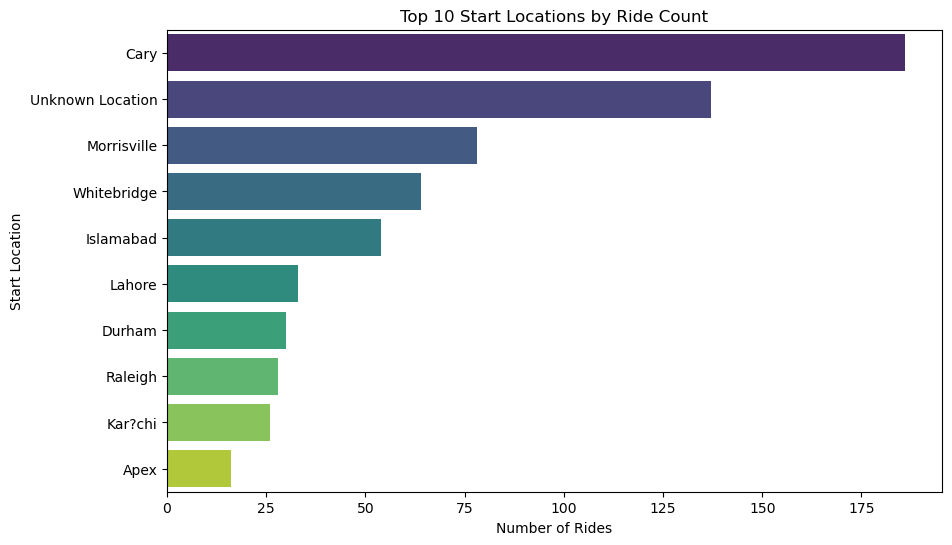

In [275]:
plt.figure(figsize=(10,6))

top_start = df['START*'].value_counts().head(10)

sns.barplot(y=top_start.index,x=top_start.values,palette='viridis')

plt.xlabel('Number of Rides')
plt.ylabel('Start Location')
plt.title('Top 10 Start Locations by Ride Count')
plt.show()

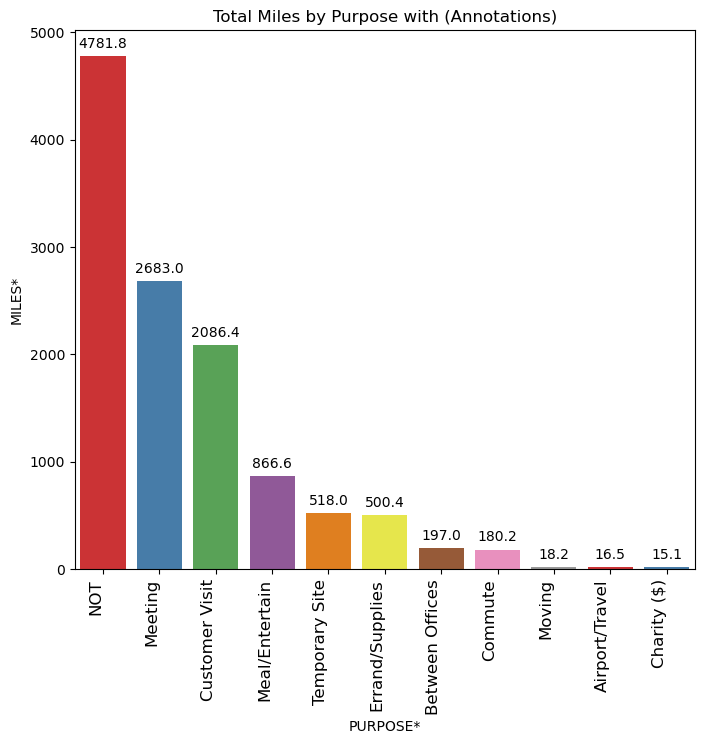

In [276]:
plt.figure(figsize = (8,7))
ax = sns.barplot(data = df, x = 'PURPOSE*', y = 'MILES*', estimator = sum, ci = None, palette = 'Set1',
                order = df.groupby('PURPOSE*')['MILES*'].sum().sort_values(ascending = False).index)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}',(p.get_x() + p.get_width()/2, p.get_height()),ha = 'center', va = 'center', xytext = (0,9), textcoords = 'offset points')

plt.xticks(rotation = 90, ha = 'right', fontsize = 12)
plt.title('Total Miles by Purpose with (Annotations)')
plt.show()

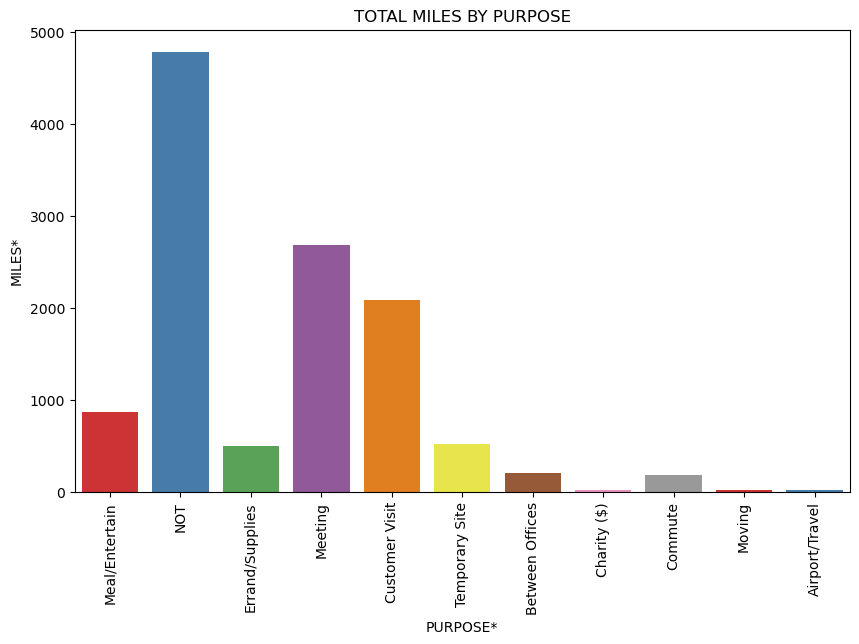

In [177]:
plt.figure(figsize = (10,6))
sns.barplot(data = df, x = 'PURPOSE*', y = 'MILES*', estimator = sum, ci = None, palette = 'Set1')
plt.xticks(rotation = 90)
plt.title('TOTAL MILES BY PURPOSE')
plt.show()

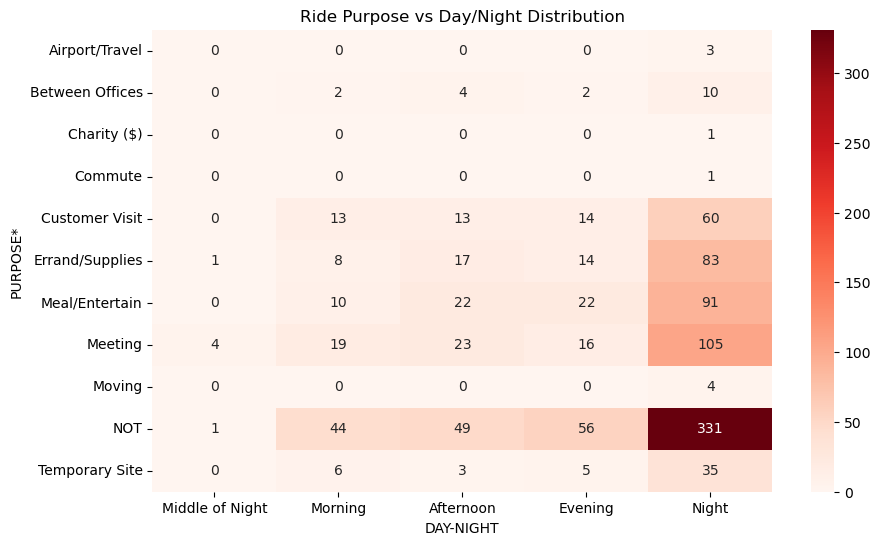

In [180]:
plt.figure(figsize = (10,6))
heatmap_data = df.groupby(['PURPOSE*', 'DAY-NIGHT']).size().unstack()
sns.heatmap(heatmap_data, annot = True, cmap = 'Reds', fmt = 'd')
plt.title("Ride Purpose vs Day/Night Distribution")
plt.show()

### Peak Hour Analysis

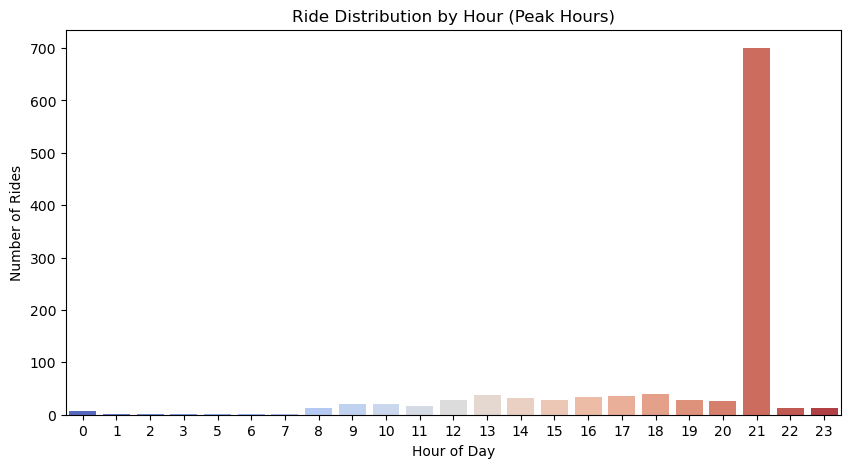

In [208]:
plt.figure(figsize=(10,5))
sns.countplot(x='TIME', data=df, palette='coolwarm')
plt.title('Ride Distribution by Hour (Peak Hours)')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Rides')
plt.show()

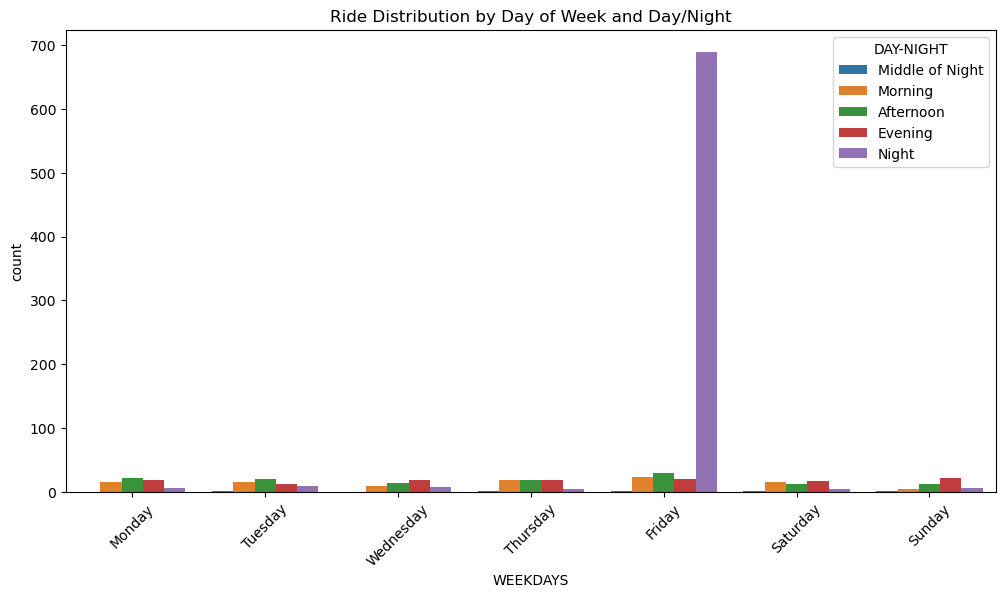

In [271]:
plt.figure(figsize=(12,6))
sns.countplot(
    data=df,
    x='WEEKDAYS',
    hue='DAY-NIGHT',
    order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
)
plt.title('Ride Distribution by Day of Week and Day/Night')
plt.xticks(rotation=45)
plt.show()

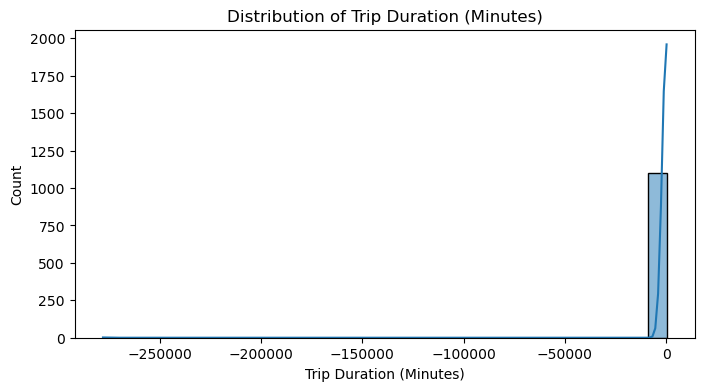

In [272]:
plt.figure(figsize=(8,4))
sns.histplot(df['MINUTES'].dt.total_seconds()/60, bins=30, kde=True)
plt.title('Distribution of Trip Duration (Minutes)')
plt.xlabel('Trip Duration (Minutes)')
plt.show()

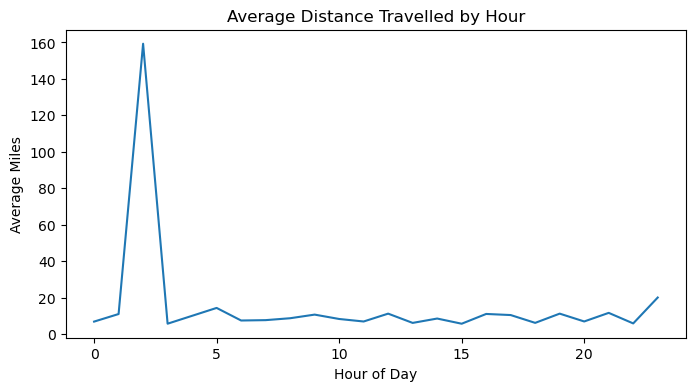

In [273]:
plt.figure(figsize=(8,4))
sns.lineplot(x='TIME', y='MILES*', data=df, ci=None)
plt.title('Average Distance Travelled by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Miles')
plt.show()

In [274]:
df[['MILES*']].describe()

,MILES*
count,1099.000000
mean,10.794540
std,22.079844
min,0.500000
25%,2.800000
50%,6.000000
75%,10.600000
max,310.300000


## KEY INSIGHTS

#### 1. Most Uber rides occur during Night hours, especially for Business category.
#### 2. Friday has the highest number of rides, indicating peak business travel.
#### 3. January shows unusually high rides, suggesting dataset concentration.
#### 4. Business rides dominate Uber usage compared to Personal rides.
#### 5. Meetings and NOT-listed purposes contribute heavily to night-time rides.
#### 6. Average ride distance spikes during early hours, indicating long-distance trips.